In [ ]:
#Explainable Deep Learning Framework for Early Detection of Chagas Disease Using ECG Signals

Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Used for interacting with folders and files
import os

base_path = "/content/drive/MyDrive/Chagas_Disease_Dataset"

print(os.listdir(base_path))

['scp_statements.csv', 'ptbxl_database.csv', 'records100']


In [ ]:
# Install libraries required for ECG analysis
!pip install wfdb -q

In [ ]:
import pandas as pd
import wfdb

print("Pandas Version:", pd.__version__)
print("WFDB Imported Successfully")

Pandas Version: 3.0.3
WFDB Imported Successfully


Import Required Libraries

In [ ]:
# Pandas is used for reading and handling CSV files
import pandas as pd

# NumPy is used for numerical computations and arrays
import numpy as np

# Matplotlib is used for plotting ECG signals
import matplotlib.pyplot as plt

# WFDB is used to read ECG waveform files (.hea and .dat)
import wfdb

# Used later for converting label strings into dictionaries
import ast

Load the Main Metadata File

In [ ]:
# Path to metadata file

metadata_path = os.path.join(base_path, "ptbxl_database.csv")

# Load metadata

df = pd.read_csv(metadata_path)

# Display first 5 rows

df.head()

,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


Understand Dataset Structure

In [ ]:
# View all column names

print(df.columns)

Index(['ecg_id', 'patient_id', 'age', 'sex', 'height', 'weight', 'nurse',
       'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis',
       'infarction_stadium1', 'infarction_stadium2', 'validated_by',
       'second_opinion', 'initial_autogenerated_report', 'validated_by_human',
       'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems',
       'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr'],
      dtype='str')


Inspect ECG Labels

In [ ]:
# View diagnosis labels

df['scp_codes'].head()

0    {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}
1                {'NORM': 80.0, 'SBRAD': 0.0}
2                  {'NORM': 100.0, 'SR': 0.0}
3                  {'NORM': 100.0, 'SR': 0.0}
4                  {'NORM': 100.0, 'SR': 0.0}
Name: scp_codes, dtype: str

Convert Labels into Dictionaries

In [ ]:
# Convert string labels into dictionaries

df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)

# Check result

df['scp_codes'].head()

0    {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}
1                {'NORM': 80.0, 'SBRAD': 0.0}
2                  {'NORM': 100.0, 'SR': 0.0}
3                  {'NORM': 100.0, 'SR': 0.0}
4                  {'NORM': 100.0, 'SR': 0.0}
Name: scp_codes, dtype: object

Examine One ECG Record

In [ ]:
# View first row

df.iloc[0]

ecg_id                                                                 1
patient_id                                                       15709.0
age                                                                 56.0
sex                                                                    1
height                                                               NaN
weight                                                              63.0
nurse                                                                2.0
site                                                                 0.0
device                                                         CS-12   E
recording_date                                       1984-11-09 09:17:34
report                            sinusrhythmus periphere niederspannung
scp_codes                       {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}
heart_axis                                                           NaN
infarction_stadium1                                

Get Path to First ECG Signal

In [ ]:
# Get low-resolution ECG file path

ecg_path = os.path.join(base_path, df.iloc[0]['filename_lr'])

print(ecg_path)

/content/drive/MyDrive/Chagas_Disease_Dataset/records100/00000/00001_lr


Load ECG Signal

In [ ]:
# Read ECG record

record = wfdb.rdrecord(ecg_path)

# Extract signal values

signal = record.p_signal

print(signal.shape)

(1000, 12)


Visualize ECG Signal

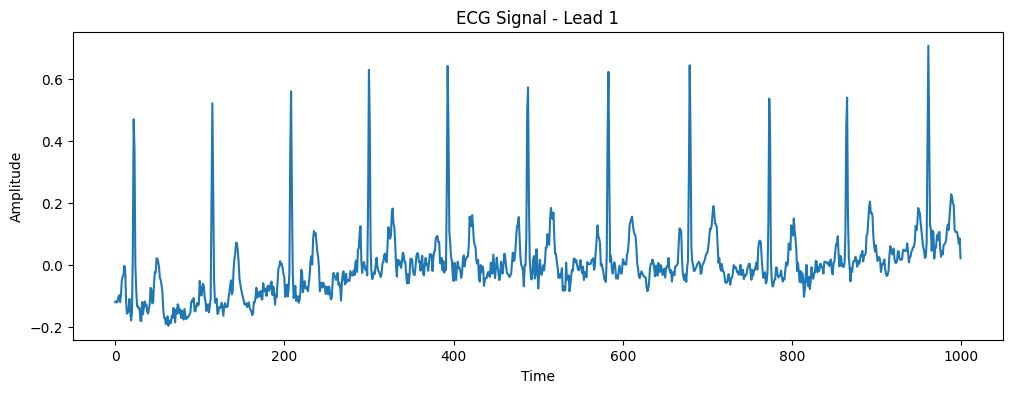

In [ ]:
plt.figure(figsize=(12,4))

plt.plot(signal[:,0])

plt.title("ECG Signal - Lead 1")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

In [ ]:
signal[:,0]

array([-0.119, -0.116, -0.12 , -0.117, -0.103, -0.097, -0.119, -0.096,
       -0.048, -0.037, -0.032, -0.002, -0.017, -0.115, -0.156, -0.153,
       -0.143, -0.109, -0.153, -0.178, -0.152,  0.043,  0.469,  0.371,
       -0.002, -0.078, -0.132, -0.132, -0.14 , -0.138, -0.179, -0.18 ,
       -0.119, -0.158, -0.138, -0.117, -0.133, -0.126, -0.149, -0.156,
       -0.139, -0.124, -0.073, -0.078, -0.123, -0.121, -0.062, -0.023,
       -0.024,  0.022,  0.021,  0.011, -0.009, -0.042, -0.048, -0.066,
       -0.088, -0.143, -0.169, -0.17 , -0.19 , -0.184, -0.165, -0.195,
       -0.188, -0.178, -0.186, -0.163, -0.169, -0.138, -0.159, -0.184,
       -0.143, -0.157, -0.126, -0.131, -0.155, -0.143, -0.17 , -0.146,
       -0.157, -0.175, -0.141, -0.158, -0.174, -0.167, -0.168, -0.165,
       -0.158, -0.153, -0.119, -0.113, -0.118, -0.106, -0.149, -0.148,
       -0.132, -0.122, -0.13 , -0.126, -0.051, -0.072, -0.098, -0.081,
       -0.06 , -0.069, -0.106, -0.119, -0.148, -0.129, -0.126, -0.152,
      

#Data Preprocessing

#PHASE 1: Understand Diagnosis Labels

Load scp_statements.csv

In [ ]:
# Load diagnosis dictionary

scp_df = pd.read_csv(
    os.path.join(base_path, "scp_statements.csv"),
    index_col=0
)

scp_df.head()

,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7


Explore Available Diagnostic Classes

In [ ]:
print(scp_df.columns)

Index(['description', 'diagnostic', 'form', 'rhythm', 'diagnostic_class',
       'diagnostic_subclass', 'Statement Category',
       'SCP-ECG Statement Description', 'AHA code', 'aECG REFID', 'CDISC Code',
       'DICOM Code'],
      dtype='str')


Keep Only Diagnostic Labels

In [ ]:
diagnostic_df = scp_df[scp_df["diagnostic"] == 1]

diagnostic_df.head()

,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7


Create Diagnostic Mapping

In [ ]:
diagnostic_map = diagnostic_df["diagnostic_class"].to_dict()

print(list(diagnostic_map.items())[:10])

[('NDT', 'STTC'), ('NST_', 'STTC'), ('DIG', 'STTC'), ('LNGQT', 'STTC'), ('NORM', 'NORM'), ('IMI', 'MI'), ('ASMI', 'MI'), ('LVH', 'HYP'), ('LAFB', 'CD'), ('ISC_', 'STTC')]


#PHASE 2: Process Labels

Extract Diagnostic Classes

In [ ]:
def extract_diagnostic_classes(scp_codes):

    classes = []

    for key in scp_codes.keys():

        if key in diagnostic_map:
            classes.append(diagnostic_map[key])

    return list(set(classes))

Apply Function

In [ ]:
df["diagnostic_classes"] = df["scp_codes"].apply(
    extract_diagnostic_classes
)

df[["scp_codes", "diagnostic_classes"]].head()

,scp_codes,diagnostic_classes
0,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",[NORM]
1,"{'NORM': 80.0, 'SBRAD': 0.0}",[NORM]
2,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
3,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
4,"{'NORM': 100.0, 'SR': 0.0}",[NORM]


Check Class Distribution

In [ ]:
df["diagnostic_classes"].explode().value_counts()

diagnostic_classes
NORM    9514
MI      5469
STTC    5235
CD      4898
HYP     2649
Name: count, dtype: int64

#PHASE 3: Simplify to One Label

Create Binary Labels

In [ ]:
def create_binary_label(classes):

    if "NORM" in classes:
        return 0

    return 1

In [ ]:
#Applying
df["label"] = df["diagnostic_classes"].apply(
    create_binary_label
)

df[["diagnostic_classes", "label"]].head()

,diagnostic_classes,label
0,[NORM],0
1,[NORM],0
2,[NORM],0
3,[NORM],0
4,[NORM],0


Check Label Balance

In [ ]:
df["label"].value_counts()

label
1    12285
0     9514
Name: count, dtype: int64

#PHASE 4: Prepare ECG Signals

Load One ECG Signal Again

In [ ]:
path = os.path.join(
    base_path,
    df.iloc[0]["filename_lr"]
)

record = wfdb.rdrecord(path)

signal = record.p_signal

print(signal.shape)

(1000, 12)


In [ ]:
#Test-Step
df["diagnostic_classes"].explode().value_counts()

diagnostic_classes
NORM    9514
MI      5469
STTC    5235
CD      4898
HYP     2649
Name: count, dtype: int64

In [ ]:
#Test-Step
df["label"].value_counts()

label
1    12285
0     9514
Name: count, dtype: int64

#SIGNAL PREPROCESSING

Load a Few ECGs First

In [ ]:
sample_df = df.head(100)

print("Samples selected:", len(sample_df))

Samples selected: 100


Create Containers

In [ ]:
signals = []
labels = []

Load ECG Signals

In [ ]:
for idx in range(len(sample_df)):

    path = os.path.join(
        base_path,
        sample_df.iloc[idx]["filename_lr"]
    )

    record = wfdb.rdrecord(path)

    signal = record.p_signal

    signals.append(signal)

    labels.append(
        sample_df.iloc[idx]["label"]
    )

print("Done")

Done


Convert to NumPy Arrays

In [ ]:
X = np.array(signals)

y = np.array(labels)

print(X.shape)
print(y.shape)

(100, 1000, 12)
(100,)


#Normalization

SMART SIGNAL NORMALIZATION

In [ ]:
def normalize_signal(signal):
    # Normalize each ECG recording individually
    return (signal - np.mean(signal, axis=0)) / (np.std(signal, axis=0) + 1e-8)

REBUILD DATASET PROPERLY

In [ ]:
signals = []
labels = []

sample_df = df.head(500)  # start small for stability

for i in range(len(sample_df)):

    path = os.path.join(base_path, sample_df.iloc[i]["filename_lr"])

    try:
        record = wfdb.rdrecord(path)
        signal = record.p_signal

        # IMPORTANT: normalize each ECG individually
        signal = normalize_signal(signal)

        signals.append(signal)
        labels.append(sample_df.iloc[i]["label"])

    except:
        # skip corrupted files safely
        continue

print("Loaded ECG samples:", len(signals))

Loaded ECG samples: 500


CONVERT TO NUMPY (MODEL FORMAT)

In [ ]:
import numpy as np

X = np.array(signals)
y = np.array(labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (500, 1000, 12)
y shape: (500,)


#TRAIN / TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

FINAL DATA SHAPE CHECK

In [ ]:
print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (400, 1000, 12) (400,)
Test: (100, 1000, 12) (100,)


Check Train/Test Percentage

In [ ]:
# Total samples
total = len(X)

# Train and test sizes
train_size = len(X_train)
test_size = len(X_test)

# Percentage calculation
train_pct = (train_size / total) * 100
test_pct = (test_size / total) * 100

print(f"Total samples: {total}")
print(f"Train samples: {train_size} ({train_pct:.2f}%)")
print(f"Test samples: {test_size} ({test_pct:.2f}%)")

Total samples: 500
Train samples: 400 (80.00%)
Test samples: 100 (20.00%)
